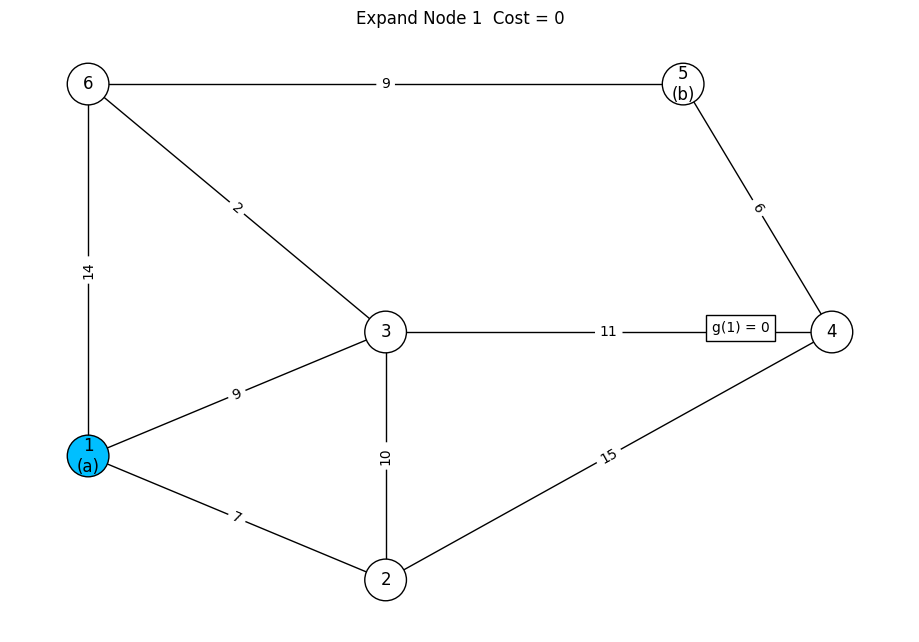

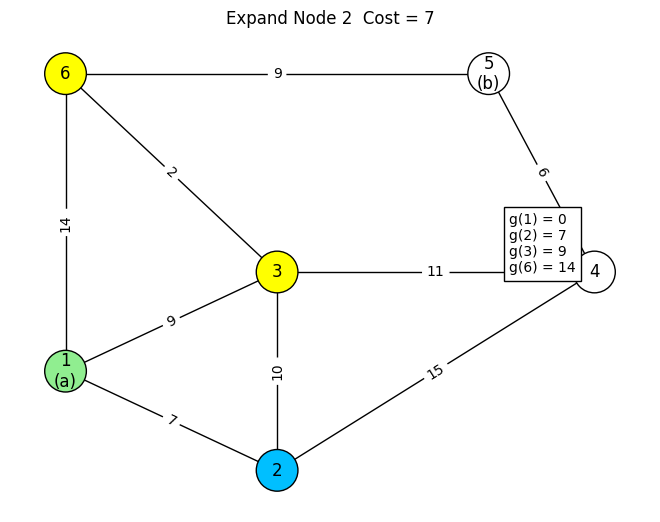

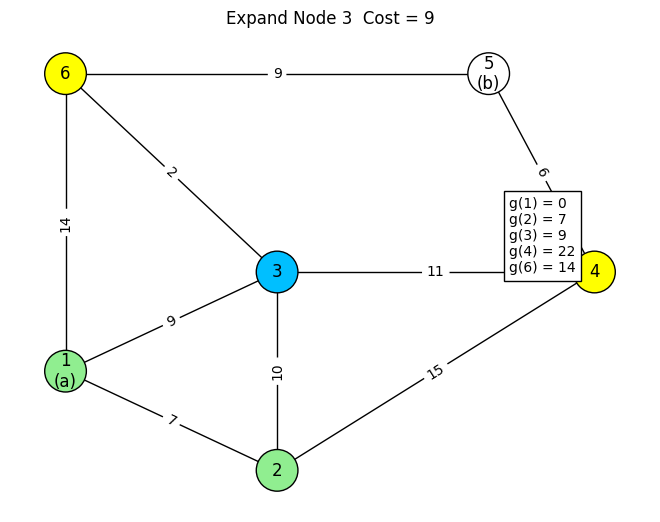

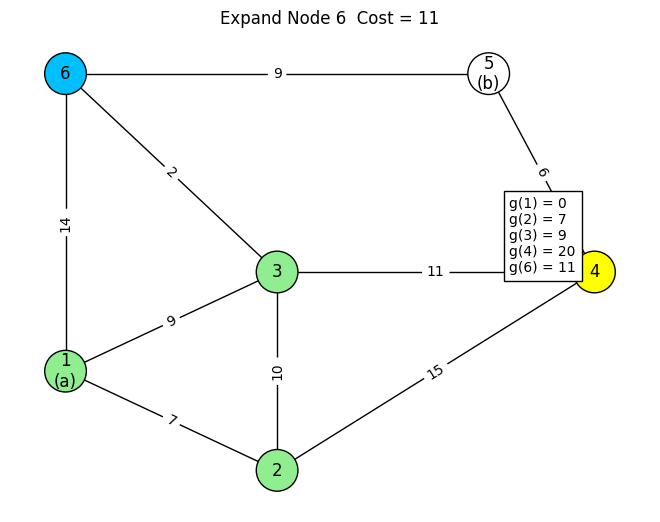

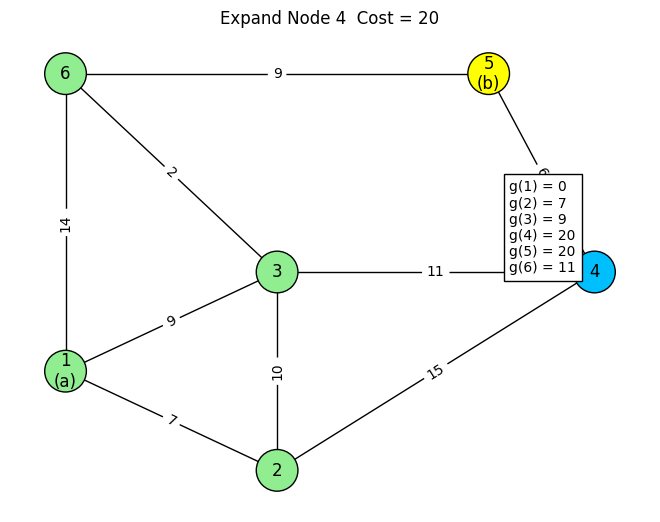

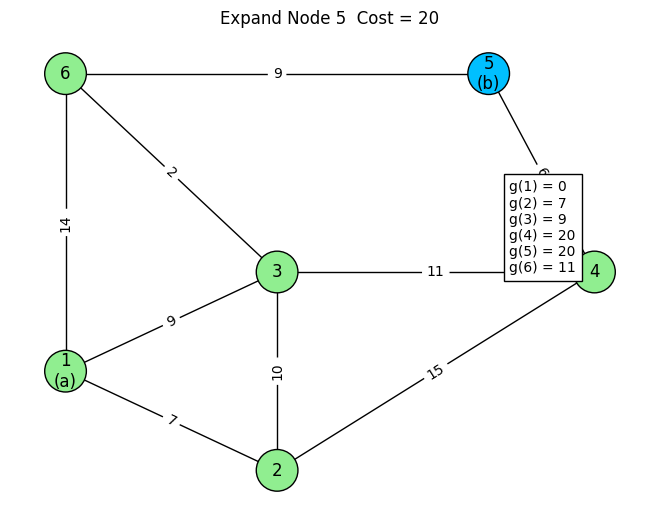

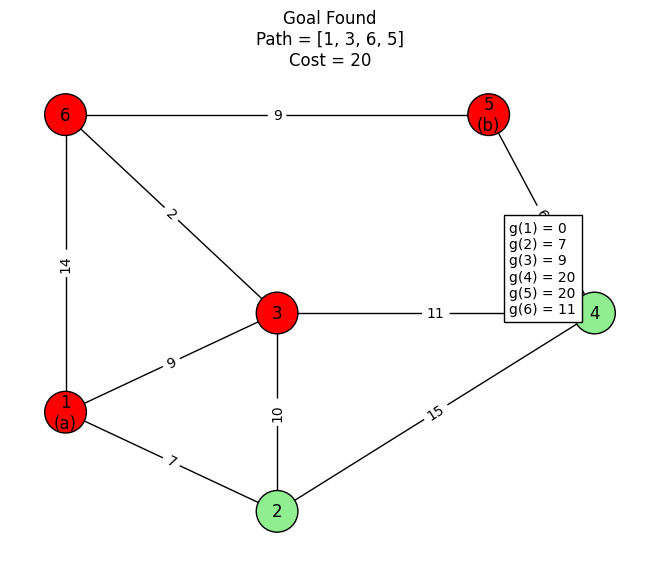

In [3]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt
graph = {
    1: [(2,7), (3,9), (6,14)],
    2: [(1,7), (3,10), (4,15)],
    3: [(1,9), (2,10), (4,11), (6,2)],
    4: [(2,15), (3,11), (5,6)],
    5: [(4,6), (6,9)],
    6: [(1,14), (3,2), (5,9)]
}
pos = {
    1:(0,0),
    2:(2,-1),
    3:(2,1),
    4:(5,1),
    5:(4,3),
    6:(0,3)
}
labels = {
    1:"1\n(a)",
    2:"2",
    3:"3",
    4:"4",
    5:"5\n(b)",
    6:"6"
}

G = nx.Graph()

for u in graph:
    for v,w in graph[u]:
        if not G.has_edge(u,v):
            G.add_edge(u,v,weight=w)
def draw(current, visited, frontier, path, costs, title):
    plt.clf()
    colors = []
    for node in G.nodes():
        if node in path:
            colors.append("red")

        elif node == current:
            colors.append("deepskyblue")

        elif node in visited:
            colors.append("lightgreen")

        elif node in frontier:
            colors.append("yellow")

        else:
            colors.append("white")
    nx.draw(
        G,
        pos,
        with_labels=False,
        node_color=colors,
        node_size=900,
        edgecolors="black"
    )

    nx.draw_networkx_labels(G,pos,labels)

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=nx.get_edge_attributes(G,"weight")
    )

    txt = "\n".join(
        [
            f"g({k}) = {v}"
            for k,v in sorted(costs.items())
        ]
    )

    plt.gcf().text(
        0.78,
        0.5,
        txt,
        bbox=dict(facecolor="white")
    )

    plt.title(title)

    plt.pause(2)

pq = [(0,1,[1])]

visited = {}

costs = {1:0}

final = []

plt.figure(figsize=(9,6))

while pq:

    frontier = {node_ for _,node_,_ in pq}

    cost,node,path = heapq.heappop(pq)

    if node in visited:
        continue

    visited[node] = cost

    draw(
        node,
        visited,
        frontier,
        [],
        costs,
        f"Expand Node {node}  Cost = {cost}"
    )

    if node == 5:
        final = path
        break

    for neighbor,weight in graph[node]:

        newCost = cost + weight

        if neighbor not in visited:

            costs[neighbor] = min(
                costs.get(neighbor,10**9),
                newCost
            )

            heapq.heappush(
                pq,
                (
                    newCost,
                    neighbor,
                    path+[neighbor]
                )
            )

draw(
    None,
    visited,
    set(),
    final,
    costs,
    f"Goal Found\nPath = {final}\nCost = {visited[5]}"
)

plt.show()